# Figure 2 (updated) — Synthetic benchmarks + embedding benchmark

Combined manuscript figure with four panels:

| Panel | Source notebook | Content |
|---|---|---|
| **a** | `Figures_notebook/Synthetic_benchmark.ipynb` (S1) | Drift-field / dynamics recovery on the double-well |
| **b** | `Figures_notebook/Synthetic_benchmark.ipynb` (S2) | Jacobian eigenspectrum, estimated vs analytic |
| **c** | `Figures_notebook/Synthetic_benchmark.ipynb` (S3) | Archetype recovery across three known regimes |
| **d** | `examples/08_embedding_benchmark.ipynb` (Cell 8 Panel A) | Composite ranking of 8 latent spaces, FA highlighted |

Panels a–c are recomputed here from the synthetic simulators (fast). Panel d is read from the cached benchmark scores in `examples/results/benchmark/benchmark_scores.csv` — re-running the full 8-method × 2-seed benchmark from scratch takes several hours on CPU and is not required.

Styling follows Nature Methods conventions: Type 42 PDF fonts, 8 pt axis labels / tick labels, 10 pt panel titles, consistent palette across the synthetic systems.

In [1]:
# ── 0. Imports & global style ────────────────────────────────────────────
import os, sys, warnings
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.optimize import linear_sum_assignment

from scjdo.tl import fit_drift
from scjdo.archetypes.decompose import jacobian_modes
from scjdo.simulate.trajectories import euler_integrate

# Nature Methods-style rcParams (Type 42 fonts, 8 pt body / 10 pt panel)
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'font.family':  'DejaVu Sans',
    'font.size':       8,
    'axes.titlesize':  10,
    'axes.labelsize':   8,
    'xtick.labelsize':  7,
    'ytick.labelsize':  7,
    'legend.fontsize':  7,
    'axes.linewidth':   0.8,
    'xtick.major.width':0.8,
    'ytick.major.width':0.8,
})

# Shared palette across the synthetic systems (matches manuscript Fig 2 a–c)
PALETTE = {
    'truth':       '#1A1A2E',
    'estimate':    '#E63946',
    'attractor':   '#2A9D8F',
    'auxiliary':   '#457B9D',
    'archetypes':  ['#E63946', '#2A9D8F', '#457B9D'],
    'highlight':   '#F4A261',   # FA highlight in panel d
    'bar_default': '#7FB7B0',   # other unsupervised methods
    'bar_super':   '#AAAAAA',   # supervised methods (e.g. PLS)
}

SEED       = 0
QUICK      = False                  # True → ~30 s smoke run, False → manuscript numbers
N_EPOCHS   = 400 if QUICK else 2000
OUTDIR     = Path('.')              # write figure next to this notebook
BENCH_CSV  = Path('../examples/results/benchmark/benchmark_scores.csv')

rng = np.random.default_rng(SEED); torch.manual_seed(SEED)
print(f'QUICK={QUICK}  N_EPOCHS={N_EPOCHS}  bench_csv_exists={BENCH_CSV.exists()}')

QUICK=False  N_EPOCHS=2000  bench_csv_exists=True


## Part 1 — Synthetic benchmarks (panels a, b, c)

Reproduces the relevant subset of `Synthetic_benchmark.ipynb`:

1. Simulate a double-well SDE; train a `DriftField` on the resulting snapshot population.
2. **S1 (panel a)** — integrate the learned field forward and compare to the noise-free truth.
3. **S2 (panel b)** — compare estimated vs analytic `max Re(λ)` of `J(x,t)` across pseudotime.
4. **S3 (panel c)** — construct a 3-regime Jacobian tensor (stable / saddle / spiral) and recover archetypes.

Panel d (S4, Schrödinger bridge) is intentionally omitted from this updated figure.

In [2]:
# ── 1. Simulate double-well snapshot & fit drift field ───────────────────
def em_simulate(drift, x0, n_steps, dt, sigma, rng):
    x = x0.copy().astype(np.float32); N, D = x.shape
    traj = np.empty((n_steps + 1, N, D), np.float32); traj[0] = x
    for i in range(n_steps):
        x = x + drift(x) * dt + sigma * np.sqrt(dt) * rng.standard_normal((N, D)).astype(np.float32)
        traj[i + 1] = x
    return traj

def dw_drift(x):
    return np.stack([-4 * x[..., 0] * (x[..., 0] ** 2 - 1.0),
                     -2.0 * x[..., 1]], -1).astype(np.float32)

def dw_jacobian(x):
    return np.array([[-4 * (3 * x[0] ** 2 - 1.0), 0.0], [0.0, -2.0]], np.float32)

GENE_NAMES = [f'G{i}' for i in range(8)]
W = np.array([[ 1.0, 0.0],[ 0.9, 0.1],[ 0.8,-0.1],
              [ 0.05, 1.0],[-0.05,0.9],
              [ 0.4, 0.4],[ 0.3,-0.5],[-0.4,0.3]], dtype=np.float32)

N, n_steps, dt, sigma = (800 if QUICK else 2000), 200, 0.01, 0.06
x0   = np.stack([0.18 + 0.03 * rng.standard_normal(N),
                 0.30 * rng.standard_normal(N)], 1).astype(np.float32)
traj = em_simulate(dw_drift, x0, n_steps, dt, sigma, rng)
ti   = rng.integers(0, n_steps + 1, size=N)
Xlat = traj[ti, np.arange(N)]
pt   = (ti / n_steps).astype(np.float32)

A = ad.AnnData(X=(Xlat @ W.T).astype(np.float32))
A.var_names      = GENE_NAMES
A.obsm['X_pca']  = Xlat.astype(np.float32)
A.obs['pseudotime'] = pt
A.varm['PCs']    = W

model = fit_drift(A, rep='X_pca', time_key='pseudotime',
                  n_epochs=N_EPOCHS, n_archetypes=3,
                  vel_scale=2.0, seed=SEED, verbose=False)
res = A.uns['scjdo']
print(f'fit_drift done | R²={res["r2"]:.3f} | cells={N} on +branch={(Xlat[:,0]>0).mean():.2f}')

fit_drift done | R²=1.000 | cells=2000 on +branch=1.00


In [3]:
# ── 2. S1 — dynamics recovery (panel a inputs) ───────────────────────────
early = Xlat[pt < 0.05]
n_int = min(300, len(early))
x0t   = torch.tensor(early[:n_int])
with torch.no_grad():
    sim_learned = euler_integrate(model, x0t, t0=0.0, t1=1.0, steps=200).numpy()
end_learned = sim_learned[:, -1, :]
end_true    = em_simulate(dw_drift, early[:n_int], 200, dt, 0.0, rng)[-1]

S1_endpoint_mse = float(((end_learned - end_true) ** 2).sum(1).mean())
S1_reach_frac   = float(np.mean(np.linalg.norm(end_learned - np.array([1.0, 0.0]), axis=1) < 0.25))

S1_true_path    = em_simulate(dw_drift, np.array([[0.18, 0.10]], np.float32), 200, dt, 0.0, rng)[:, 0, :]
with torch.no_grad():
    S1_learned_path = euler_integrate(model,
        torch.tensor([[0.18, 0.10]], dtype=torch.float32),
        t0=0.0, t1=1.0, steps=200).numpy()[0]

print(f'S1  endpoint MSE = {S1_endpoint_mse:.4f} | fraction reaching +well = {S1_reach_frac:.2f}')

S1  endpoint MSE = 0.0005 | fraction reaching +well = 1.00


In [4]:
# ── 3. S2 — Jacobian eigenspectrum (panel b inputs) ──────────────────────
J  = res['J_tensor']
J  = J.numpy() if hasattr(J, 'numpy') else np.asarray(J)
tc = np.asarray(res['t_centers'])

S2_t, S2_est, S2_true = [], [], []
for i, tci in enumerate(tc):
    sel = np.abs(pt - tci) < 0.08
    if sel.sum() < 3:
        continue
    S2_t.append(float(tci))
    S2_est.append(float(np.linalg.eigvals(J[i]).real.max()))
    S2_true.append(float(np.linalg.eigvals(dw_jacobian(Xlat[sel].mean(0))).real.max()))
S2_t, S2_est, S2_true = map(np.asarray, (S2_t, S2_est, S2_true))
S2_corr = float(np.corrcoef(S2_est, S2_true)[0, 1])
print(f'S2  eigenvalue correlation = {S2_corr:.3f} | sign transition recovered: '
      f'{np.sign(S2_est[0])>0 and np.sign(S2_est[-1])<0}')

S2  eigenvalue correlation = 0.787 | sign transition recovered: True


In [5]:
# ── 4. S3 — archetype recovery (panel c inputs) ──────────────────────────
T = 30
regime_bounds = [(0, 10), (10, 20), (20, 30)]
regime_base = {
    0: np.array([[-2.0, 0.0], [0.0, -2.0]]),    # stable
    1: np.array([[ 3.0, 0.0], [0.0, -2.0]]),    # saddle / bifurcating
    2: np.array([[-0.2, -2.0], [2.0, -0.2]]),   # stable spiral / oscillatory
}
Jt = np.zeros((T, 2, 2), np.float32)
for i in range(T):
    r = 0 if i < 10 else (1 if i < 20 else 2)
    Jt[i] = regime_base[r] + 0.05 * rng.standard_normal((2, 2))

S3_patterns, S3_acts, S3_err = jacobian_modes(torch.tensor(Jt), rank=3, seed=SEED)
S3_acts = S3_acts.numpy()
regime_of = lambda w: 0 if w < 10 else (1 if w < 20 else 2)
S3_peak   = [int(np.argmax(S3_acts[:, k])) for k in range(3)]
S3_map    = [regime_of(w) for w in S3_peak]
S3_distinct = len(set(S3_map)) == 3
print(f'S3  peak windows = {S3_peak} → regimes {S3_map} | 3 distinct = {S3_distinct} | err = {S3_err:.3f}')

S3  peak windows = [19, 29, 2] → regimes [1, 2, 0] | 3 distinct = True | err = 0.228


## Part 2 — Embedding benchmark (panel d)

Loads the pre-computed composite ranking from `examples/results/benchmark/benchmark_scores.csv`. FactorAnalysis is highlighted to flag the latent space adopted for downstream scJDO analyses.

In [6]:
# ── 5. Load benchmark scores ─────────────────────────────────────────────
if not BENCH_CSV.exists():
    raise FileNotFoundError(
        f'{BENCH_CSV} not found. Run examples/08_embedding_benchmark.ipynb '
        'end-to-end first (it writes the CSV alongside benchmark_figure.pdf).'
    )

bench = pd.read_csv(BENCH_CSV).sort_values('composite', ascending=False).reset_index(drop=True)
print(bench[['method', 'supervised', 'composite']])

           method  supervised  composite
0             PLS        True      0.670
1  FactorAnalysis       False      0.656
2            scVI       False      0.597
3           LDVAE       False      0.586
4    TruncatedSVD       False      0.582
5             ICA       False      0.580
6             PCA       False      0.553
7         DiffMap       False      0.397


## Combined figure — 2×2 layout (a b / c d)

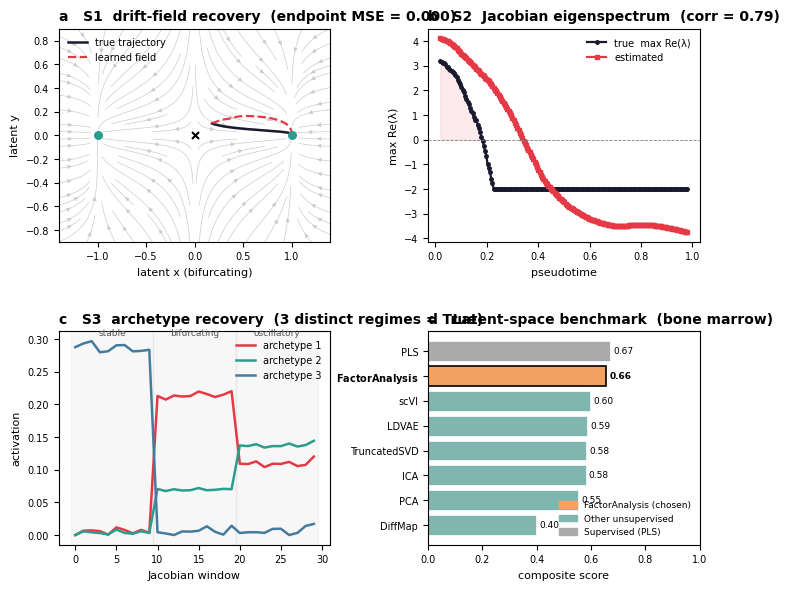

Saved → figure_2_updated.pdf  &  figure_2_updated.png


In [7]:
# ── 6. Render the combined manuscript figure ────────────────────────────
fig = plt.figure(figsize=(7.2, 6.0))   # Nature Methods double-column = 7.2 in
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.36,
                        left=0.08, right=0.97, top=0.94, bottom=0.08)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ──────────────────────────────────────────────────────────────────────────
# Panel a — S1 drift-field / dynamics recovery
# ──────────────────────────────────────────────────────────────────────────
gx, gy = np.meshgrid(np.linspace(-1.4, 1.4, 22), np.linspace(-0.9, 0.9, 14))
Gv = dw_drift(np.stack([gx, gy], -1))
ax_a.streamplot(gx, gy, Gv[..., 0], Gv[..., 1],
                 color='#cccccc', density=1.0, linewidth=0.5, arrowsize=0.6)
ax_a.plot(S1_true_path[:, 0],    S1_true_path[:, 1],
           '-',  color=PALETTE['truth'],    lw=1.8, label='true trajectory')
ax_a.plot(S1_learned_path[:, 0], S1_learned_path[:, 1],
           '--', color=PALETTE['estimate'], lw=1.6, label='learned field')
ax_a.scatter([-1, 1], [0, 0], c=PALETTE['attractor'], s=30, zorder=5)
ax_a.scatter([0], [0], marker='x', c='k', s=25, zorder=5)
ax_a.set_title(f'a   S1  drift-field recovery  (endpoint MSE = {S1_endpoint_mse:.3f})',
                fontweight='bold', loc='left')
ax_a.set_xlabel('latent x (bifurcating)')
ax_a.set_ylabel('latent y')
ax_a.legend(loc='upper left', frameon=False)
ax_a.set_xlim(-1.4, 1.4); ax_a.set_ylim(-0.9, 0.9)

# ──────────────────────────────────────────────────────────────────────────
# Panel b — S2 Jacobian eigenspectrum
# ──────────────────────────────────────────────────────────────────────────
ax_b.plot(S2_t, S2_true, '-o', color=PALETTE['truth'],
           ms=2.5, lw=1.6, label='true  max Re(λ)')
ax_b.plot(S2_t, S2_est,  '-s', color=PALETTE['estimate'],
           ms=2.5, lw=1.6, label='estimated')
ax_b.axhline(0, color='gray', lw=0.6, ls='--')
ax_b.fill_between(S2_t, 0, S2_true, where=(S2_true > 0),
                   color=PALETTE['estimate'], alpha=0.10)
ax_b.set_title(f'b   S2  Jacobian eigenspectrum  (corr = {S2_corr:.2f})',
                fontweight='bold', loc='left')
ax_b.set_xlabel('pseudotime')
ax_b.set_ylabel('max Re(λ)')
ax_b.legend(frameon=False)

# ──────────────────────────────────────────────────────────────────────────
# Panel c — S3 archetype recovery
# ──────────────────────────────────────────────────────────────────────────
for k in range(3):
    ax_c.plot(np.arange(T), S3_acts[:, k],
               color=PALETTE['archetypes'][k], lw=1.8,
               label=f'archetype {k+1}')
for (lo, hi), lab in zip(regime_bounds, ['stable', 'bifurcating', 'oscillatory']):
    ax_c.axvspan(lo - 0.5, hi - 0.5, color='gray', alpha=0.06)
    ax_c.text((lo + hi) / 2 - 0.5, S3_acts.max() * 1.02, lab,
               ha='center', va='bottom', fontsize=6.5, color='#555')
ax_c.set_title(f'c   S3  archetype recovery  (3 distinct regimes = {S3_distinct})',
                fontweight='bold', loc='left')
ax_c.set_xlabel('Jacobian window')
ax_c.set_ylabel('activation')
ax_c.legend(frameon=False, loc='upper right')

# ──────────────────────────────────────────────────────────────────────────
# Panel d — Embedding benchmark composite ranking (FA highlighted)
# ──────────────────────────────────────────────────────────────────────────
methods    = bench['method'].tolist()
composites = bench['composite'].to_numpy()
supervised = bench['supervised'].astype(bool).to_numpy()

def bar_color(m, sup):
    if m == 'FactorAnalysis':
        return PALETTE['highlight']
    return PALETTE['bar_super'] if sup else PALETTE['bar_default']

colors_d = [bar_color(m, s) for m, s in zip(methods, supervised)]
edge_d   = ['black' if m == 'FactorAnalysis' else 'white' for m in methods]
lw_d     = [1.2     if m == 'FactorAnalysis' else 0.5     for m in methods]

y_pos = np.arange(len(methods))
ax_d.barh(y_pos, composites, color=colors_d,
           edgecolor=edge_d, linewidth=lw_d)
ax_d.set_yticks(y_pos)
ax_d.set_yticklabels(
    [f'$\\bf{{{m}}}$' if m == 'FactorAnalysis' else m for m in methods]
)
ax_d.invert_yaxis()
ax_d.set_xlim(0, 1.0)
ax_d.set_xlabel('composite score')
ax_d.set_title('d   Latent-space benchmark  (bone marrow)',
                fontweight='bold', loc='left')
for i, v in enumerate(composites):
    ax_d.text(v + 0.012, i, f'{v:.2f}',
               va='center', fontsize=6.5,
               fontweight='bold' if methods[i] == 'FactorAnalysis' else 'normal')

ax_d.legend(
    handles=[
        Patch(color=PALETTE['highlight'],   label='FactorAnalysis (chosen)'),
        Patch(color=PALETTE['bar_default'], label='Other unsupervised'),
        Patch(color=PALETTE['bar_super'],   label='Supervised (PLS)'),
    ],
    loc='lower right', frameon=False, fontsize=6.5,
)

# ── Save ────────────────────────────────────────────────────────────────
fig_pdf = OUTDIR / 'figure_2_updated.pdf'
fig_png = OUTDIR / 'figure_2_updated.png'
fig.savefig(fig_pdf, dpi=600, bbox_inches='tight')
fig.savefig(fig_png, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_pdf}  &  {fig_png}')

In [8]:
# ── 7. Metrics for the figure legend / methods text ─────────────────────
import json
metrics = {
    'S1_drift_endpoint_mse':       S1_endpoint_mse,
    'S1_fraction_reaching_well':   S1_reach_frac,
    'S2_eigenvalue_correlation':   S2_corr,
    'S2_sign_transition_recovered': bool(np.sign(S2_est[0]) > 0 and np.sign(S2_est[-1]) < 0),
    'S3_three_distinct_regimes':   bool(S3_distinct),
    'S3_reconstruction_error':     float(S3_err),
    'D_top_method':                methods[0],
    'D_top_unsupervised':          next(m for m, s in zip(methods, supervised) if not s),
    'D_FA_composite':              float(bench.loc[bench.method == 'FactorAnalysis', 'composite'].iat[0]),
}
(OUTDIR / 'figure_2_updated_metrics.json').write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

{
  "S1_drift_endpoint_mse": 0.0004933794843964279,
  "S1_fraction_reaching_well": 1.0,
  "S2_eigenvalue_correlation": 0.7867126851637218,
  "S2_sign_transition_recovered": true,
  "S3_three_distinct_regimes": true,
  "S3_reconstruction_error": 0.22826671002328885,
  "D_top_method": "PLS",
  "D_top_unsupervised": "FactorAnalysis",
  "D_FA_composite": 0.656
}
